In [1]:
import pandas as pd

In [2]:
# Session IDs are generated in the unified dataset builder, so validate that file directly.
data = pd.read_csv('../../data/processed/unified_environment_focus_dataset.csv', parse_dates=['timestamp'])

In [3]:
data.head()

,timestamp,session_id,location_id,record_id,source,humidity,light,temperature,noise,co2,focus_score
0,2013-08-23 16:06:00+00:00,keti_1min_resampled__510__s00001,510,keti_1min_resampled:row_00192329,keti_1min_resampled,NaN,NaN,NaN,NaN,316.000000,NaN
1,2013-08-23 16:24:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011995,keti_1min_resampled,NaN,NaN,NaN,NaN,476.555556,NaN
2,2013-08-23 16:25:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011996,keti_1min_resampled,NaN,NaN,NaN,NaN,480.333333,NaN
3,2013-08-23 16:26:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011997,keti_1min_resampled,NaN,NaN,NaN,NaN,485.166667,NaN
4,2013-08-23 16:27:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011998,keti_1min_resampled,NaN,NaN,NaN,NaN,481.083333,NaN


In [4]:
# distinct values of session_id
data['session_id'].nunique()

227

Sessions checked: 227
Problem sessions: 0


,session_id,problem


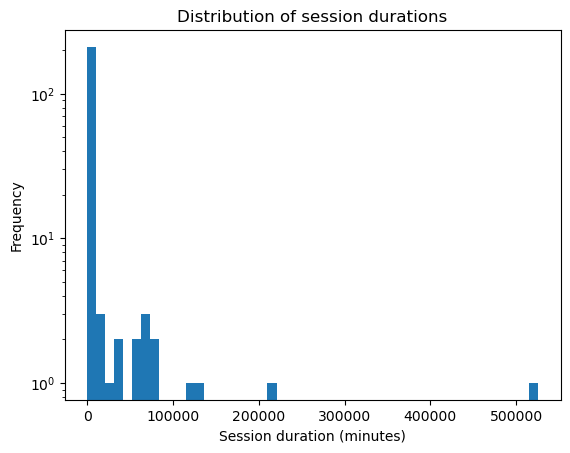

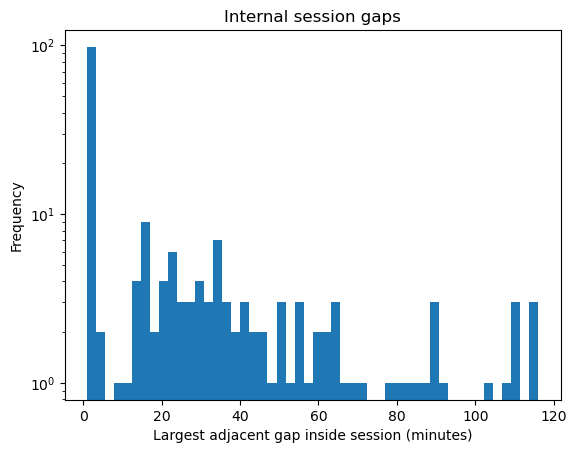

In [5]:
# For each session, check that it stays within one source/location and that
# adjacent timestamps inside a session do not cross the 2-hour split threshold.
import matplotlib.pyplot as plt

session_groups = data.sort_values(['source', 'location_id', 'timestamp']).groupby('session_id')
timediffs = []
max_internal_gaps = []
bad_sessions = []

for session_id, group in session_groups:
    source_count = group['source'].nunique()
    location_count = group['location_id'].nunique()
    if source_count > 1 or location_count > 1:
        bad_sessions.append((session_id, 'multiple source/location values'))

    timestamp_diff = group['timestamp'].max() - group['timestamp'].min()
    timediffs.append(timestamp_diff.total_seconds() / 60)

    gaps = group['timestamp'].sort_values().diff().dropna()
    if not gaps.empty:
        max_gap_minutes = gaps.max().total_seconds() / 60
        max_internal_gaps.append(max_gap_minutes)
        if max_gap_minutes > 120:
            bad_sessions.append((session_id, f'internal gap {max_gap_minutes:.1f} minutes'))

print(f'Sessions checked: {len(timediffs):,}')
print(f'Problem sessions: {len(bad_sessions):,}')
display(pd.DataFrame(bad_sessions, columns=['session_id', 'problem']).head(20))

plt.hist(timediffs, bins=50)
plt.xlabel('Session duration (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of session durations')
plt.yscale('log')
plt.show()

plt.hist(max_internal_gaps, bins=50)
plt.xlabel('Largest adjacent gap inside session (minutes)')
plt.ylabel('Frequency')
plt.title('Internal session gaps')
plt.yscale('log')
plt.show()

In [6]:
data.head()

,timestamp,session_id,location_id,record_id,source,humidity,light,temperature,noise,co2,focus_score
0,2013-08-23 16:06:00+00:00,keti_1min_resampled__510__s00001,510,keti_1min_resampled:row_00192329,keti_1min_resampled,NaN,NaN,NaN,NaN,316.000000,NaN
1,2013-08-23 16:24:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011995,keti_1min_resampled,NaN,NaN,NaN,NaN,476.555556,NaN
2,2013-08-23 16:25:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011996,keti_1min_resampled,NaN,NaN,NaN,NaN,480.333333,NaN
3,2013-08-23 16:26:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011997,keti_1min_resampled,NaN,NaN,NaN,NaN,485.166667,NaN
4,2013-08-23 16:27:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011998,keti_1min_resampled,NaN,NaN,NaN,NaN,481.083333,NaN
